# [과제3] 특성 공학(Feature Engineering) 파이프라인 구현 및 성능 비교 실험

2243232 김은서

## STEP 00. 라이브러리 불러오기

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)

## STEP 01. 데이터 준비

In [2]:
# Titanic Dataset 사용
# https://www.kaggle.com/competitions/titanic/data - train.csv

df = pd.read_csv('train.csv')
data_source = 'Kaggle Titanic train.csv'

print('Data source:', data_source)
print('Shape:', df.shape)

display(df.head())

Data source: Kaggle Titanic train.csv
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
column_meaning = {
    'PassengerId': '승객 고유 번호',
    'Survived': '생존 여부 (0=사망, 1=생존)',
    'Pclass': '객실 등급',
    'Name': '승객 이름',
    'Sex': '성별',
    'Age': '나이',
    'SibSp': '형제/배우자 동승 수',
    'Parch': '부모/자녀 동승 수',
    'Ticket': '티켓 번호',
    'Fare': '운임 요금',
    'Cabin': '객실 번호',
    'Embarked': '승선 항구'
}

column_desc = pd.DataFrame({
    '컬럼': df.columns,
    '자료형': [str(df[c].dtype) for c in df.columns],
    '결측치 수': [df[c].isna().sum() for c in df.columns],
    '설명': [column_meaning.get(c, '-') for c in df.columns]
})

display(column_desc)

,컬럼,자료형,결측치 수,설명
0,PassengerId,int64,0,승객 고유 번호
1,Survived,int64,0,"생존 여부 (0=사망, 1=생존)"
2,Pclass,int64,0,객실 등급
3,Name,object,0,승객 이름
4,Sex,object,0,성별
5,Age,float64,177,나이
6,SibSp,int64,0,형제/배우자 동승 수
7,Parch,int64,0,부모/자녀 동승 수
8,Ticket,object,0,티켓 번호
9,Fare,float64,0,운임 요금


## STEP 02. 탐색적 데이터 분석 (EDA)

,missing_count,missing_ratio
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


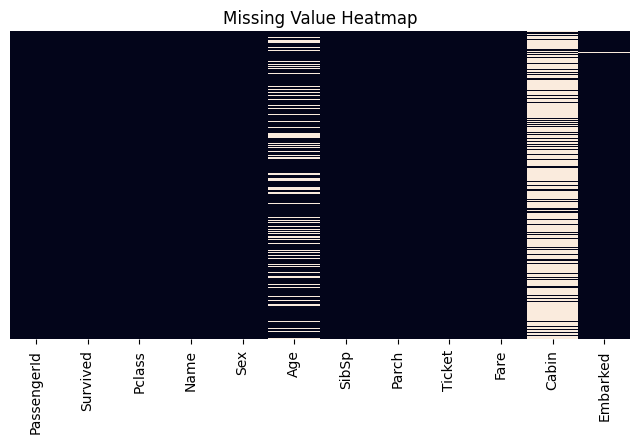

In [4]:
# 결측치 비율 분석

missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_ratio': df.isna().mean() * 100
}).sort_values('missing_ratio', ascending=False)

display(missing[missing['missing_count'] > 0])

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap')
plt.show()

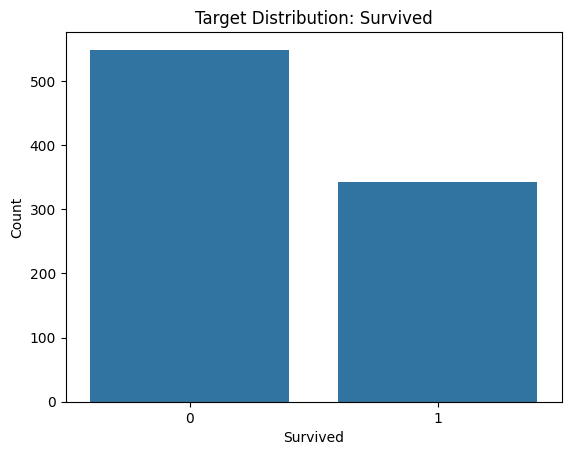

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [5]:
# 타겟 변수 분포 확인

sns.countplot(data=df, x='Survived')
plt.title('Target Distribution: Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

print(df['Survived'].value_counts(normalize=True))

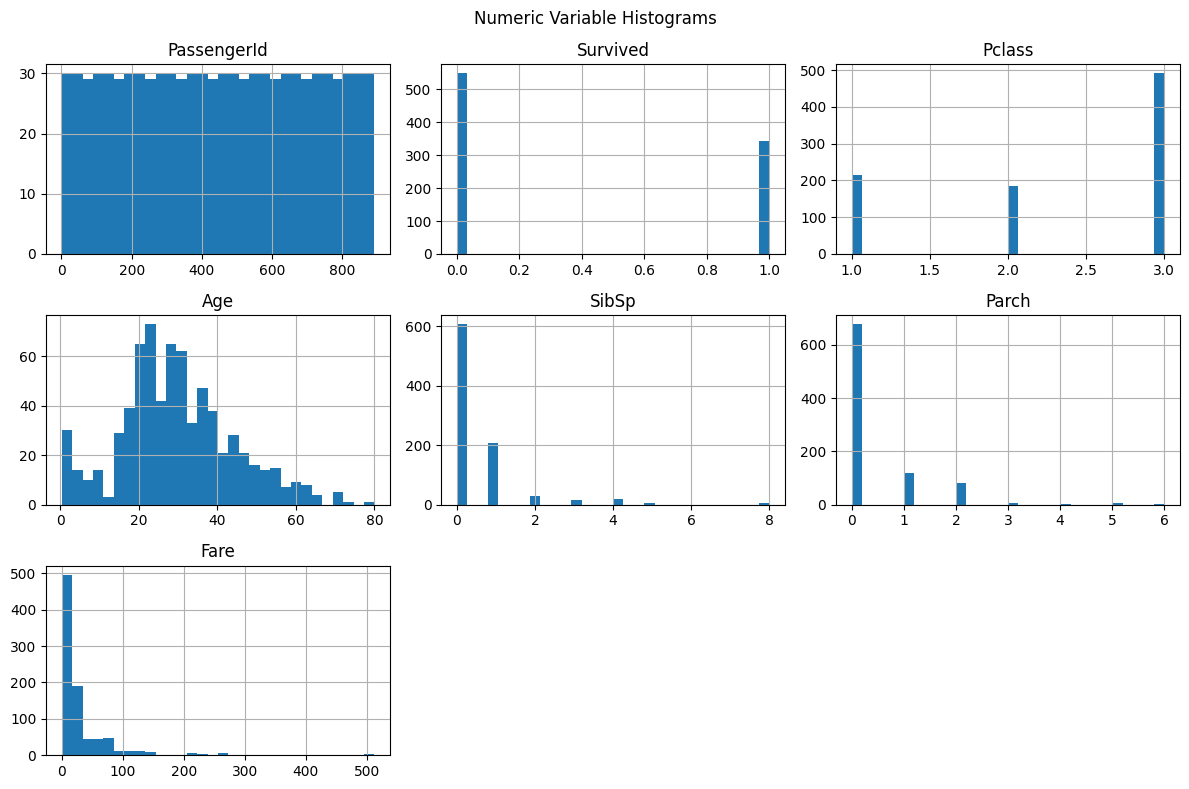

In [6]:
# 변수 분포 시각화: Histogram

num_cols_for_eda = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols_for_eda].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle('Numeric Variable Histograms')
plt.tight_layout()
plt.show()

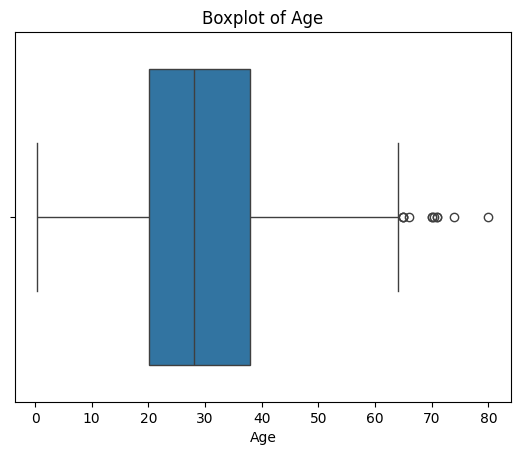

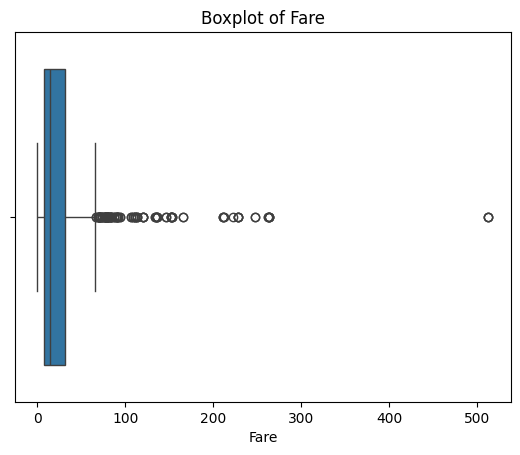

In [7]:
# 이상치 탐색: Boxplot

for col in ['Age', 'Fare']:
    if col in df.columns:
        sns.boxplot(data=df, x=col)
        plt.title(f'Boxplot of {col}')
        plt.show()

In [8]:
# IQR 기반 이상치 수 계산

outlier_rows = []

for col in df.select_dtypes(include=np.number).columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    cnt = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_rows.append([col, cnt, lower, upper])

display(
    pd.DataFrame(
        outlier_rows,
        columns=[
            'column',
            'outlier_count',
            'lower_bound',
            'upper_bound'
        ]
    )
)

,column,outlier_count,lower_bound,upper_bound
0,PassengerId,0,-444.0000,1336.0000
1,Survived,0,-1.5000,2.5000
2,Pclass,0,0.5000,4.5000
3,Age,11,-6.6875,64.8125
4,SibSp,46,-1.5000,2.5000
5,Parch,213,0.0000,0.0000
6,Fare,116,-26.7240,65.6344


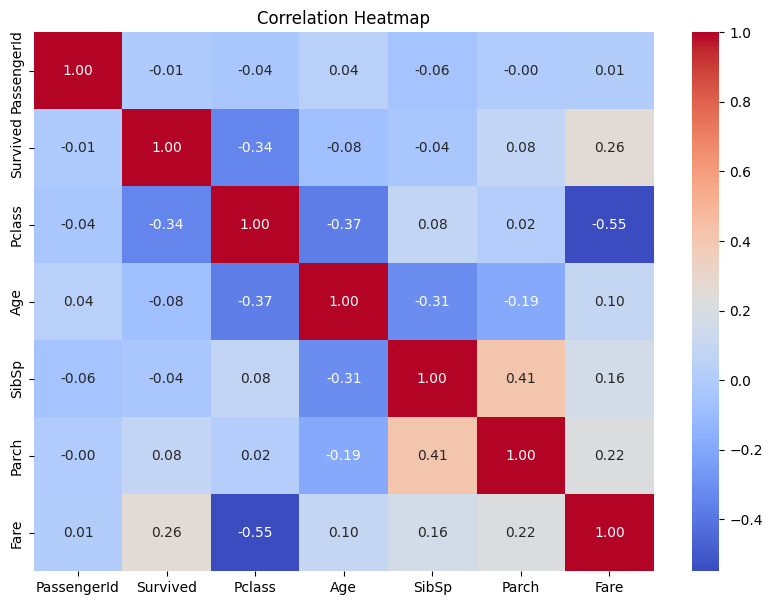

In [9]:
# 상관관계 분석: Heatmap

plt.figure(figsize=(10, 7))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

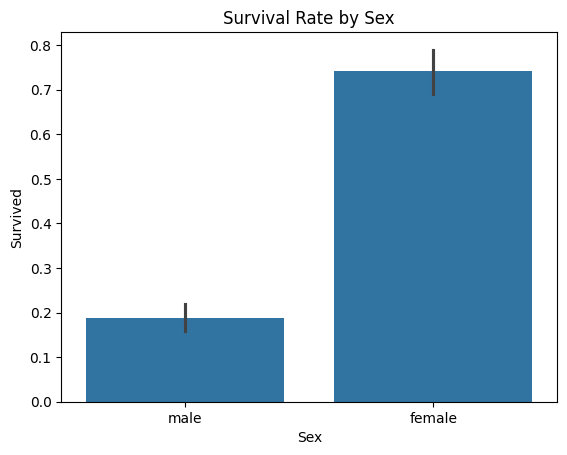

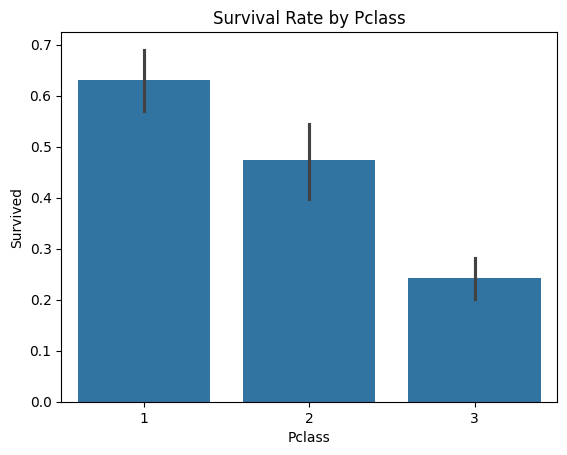

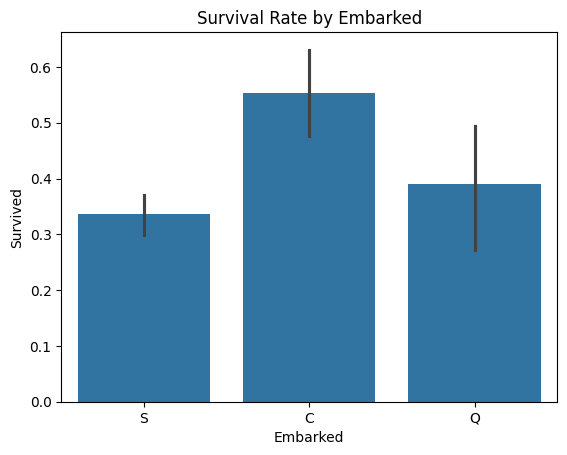

In [10]:
# 범주형 변수와 생존율 관계: Barplot

for col in ['Sex', 'Pclass', 'Embarked']:
    if col in df.columns:

        sns.barplot(
            data=df,
            x=col,
            y='Survived'
        )

        plt.title(f'Survival Rate by {col}')
        plt.show()

## STEP 03. 특성 공학 파이프라인 구현

In [11]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    '''Titanic 전용 파생변수 생성기'''

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # 파생변수 1: 가족 수
        X['FamilySize'] = (
            X.get('SibSp', 0)
            + X.get('Parch', 0)
            + 1
        )

        # 파생변수 2: 혼자 탑승 여부
        X['IsAlone'] = (
            X['FamilySize'] == 1
        ).astype(int)

        # 파생변수 3: 1인당 요금
        if 'Fare' in X.columns:
            X['FarePerPerson'] = (
                X['Fare']
                / X['FamilySize'].replace(0, 1)
            )

        # 파생변수 4: Cabin 정보 존재 여부
        if 'Cabin' in X.columns:
            X['HasCabin'] = (
                X['Cabin'].notna()
            ).astype(int)

        # 파생변수 5: 호칭(Title) 추출
        if 'Name' in X.columns:

            X['Title'] = (
                X['Name']
                .str.extract(
                    r' ([A-Za-z]+)\.',
                    expand=False
                )
                .fillna('Unknown')
            )

            rare_titles = [
                'Lady', 'Countess', 'Capt', 'Col',
                'Don', 'Dr', 'Major', 'Rev',
                'Sir', 'Jonkheer', 'Dona'
            ]

            X['Title'] = X['Title'].replace(
                rare_titles,
                'Rare'
            )

            X['Title'] = X['Title'].replace({
                'Mlle': 'Miss',
                'Ms': 'Miss',
                'Mme': 'Mrs'
            })

        else:
            X['Title'] = 'Unknown'

        # 파생변수 6: 나이 구간
        if 'Age' in X.columns:
            X['AgeGroup'] = pd.cut(
                X['Age'],
                bins=[0, 12, 19, 35, 60, 100],
                labels=[
                    'Child',
                    'Teen',
                    'YoungAdult',
                    'Adult',
                    'Senior'
                ]
            )

        return X

In [12]:
# 학습에 사용할 변수 설정

target = 'Survived'

drop_cols = (
    [target, 'Alive']
    if 'Alive' in df.columns
    else [target]
)

X = df.drop(
    columns=[
        c for c in drop_cols
        if c in df.columns
    ]
)

y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)

(712, 11) (179, 11)


In [13]:
def make_pipeline_config(
    impute_strategy='mean',
    encoder='onehot',
    scaler='standard',
    feature_selection=False,
    model=None
):
    if model is None:
        model = LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )

    # TitanicFeatureEngineer 이후 존재할 컬럼 기준
    numeric_features = [
        'Pclass',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'FamilySize',
        'IsAlone',
        'FarePerPerson',
        'HasCabin'
    ]

    categorical_features = [
        'Sex',
        'Embarked',
        'Title',
        'AgeGroup'
    ]

    # TitanicFeatureEngineer가 대부분의 파생변수를 생성하도록 설계함
    if impute_strategy in ['mean', 'median']:
        num_imputer = SimpleImputer(
            strategy=impute_strategy
        )

    elif impute_strategy == 'most_frequent':
        num_imputer = SimpleImputer(
            strategy='most_frequent'
        )

    else:
        num_imputer = SimpleImputer(
            strategy='median'
        )

    cat_imputer = SimpleImputer(
        strategy='most_frequent'
    )

    if scaler == 'standard':
        scaler_obj = StandardScaler()

    elif scaler == 'minmax':
        scaler_obj = MinMaxScaler()

    elif scaler == 'robust':
        scaler_obj = RobustScaler()

    else:
        scaler_obj = 'passthrough'

    if encoder == 'onehot':
        encoder_obj = OneHotEncoder(
            handle_unknown='ignore'
        )

    elif encoder == 'label':
        # ML 파이프라인에서는 LabelEncoder 대신 OrdinalEncoder를 사용
        encoder_obj = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )

    else:
        encoder_obj = 'passthrough'

    numeric_pipeline = Pipeline([
        ('imputer', num_imputer),
        ('scaler', scaler_obj)
    ])

    categorical_pipeline = Pipeline([
        ('imputer', cat_imputer),
        ('encoder', encoder_obj)
    ])

    preprocessor = ColumnTransformer(
        [
            (
                'num',
                numeric_pipeline,
                numeric_features
            ),
            (
                'cat',
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder='drop'
    )

    steps = [
        (
            'feature_engineering',
            TitanicFeatureEngineer()
        ),
        (
            'preprocess',
            preprocessor
        )
    ]

    if feature_selection:
        steps.append(
            (
                'feature_selection',
                SelectKBest(
                    score_func=f_classif,
                    k=10
                )
            )
        )

    steps.append(
        (
            'model',
            model
        )
    )

    return Pipeline(steps)

## STEP 04~05. 모델 학습, 변수 선택, 성능 평가

In [14]:
def evaluate_model(
    name,
    pipeline,
    X_train,
    X_test,
    y_train,
    y_test
):
    pipeline.fit(
        X_train,
        y_train
    )

    pred = pipeline.predict(X_test)

    if hasattr(
        pipeline.named_steps['model'],
        'predict_proba'
    ):
        proba = pipeline.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            proba
        )

    else:
        roc_auc = np.nan

    return {
        'Experiment': name,
        'Accuracy': accuracy_score(
            y_test,
            pred
        ),
        'Precision': precision_score(
            y_test,
            pred
        ),
        'Recall': recall_score(
            y_test,
            pred
        ),
        'F1-score': f1_score(
            y_test,
            pred
        ),
        'ROC-AUC': roc_auc
    }, pred

In [15]:
# Base: 전처리 없음에 가깝게,
# 수치형 변수만 사용하고 결측 행 제거 후 RandomForest 학습

base_features = [
    c for c in [
        'Pclass',
        'Age',
        'SibSp',
        'Parch',
        'Fare'
    ]
    if c in df.columns
]

base_df = df[
    [target] + base_features
].dropna()

X_base = base_df[base_features]

y_base = base_df[target].astype(int)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    stratify=y_base,
    random_state=RANDOM_STATE
)

base_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

base_model.fit(
    Xb_train,
    yb_train
)

base_pred = base_model.predict(Xb_test)

base_proba = base_model.predict_proba(Xb_test)[:, 1]

base_result = {
    'Experiment': 'Base',
    'Accuracy': accuracy_score(
        yb_test,
        base_pred
    ),
    'Precision': precision_score(
        yb_test,
        base_pred
    ),
    'Recall': recall_score(
        yb_test,
        base_pred
    ),
    'F1-score': f1_score(
        yb_test,
        base_pred
    ),
    'ROC-AUC': roc_auc_score(
        yb_test,
        base_proba
    )
}

base_result

{'Experiment': 'Base',
 'Accuracy': 0.6573426573426573,
 'Precision': 0.5818181818181818,
 'Recall': 0.5517241379310345,
 'F1-score': 0.5663716814159292,
 'ROC-AUC': np.float64(0.6983772819472617)}

In [16]:
experiments = [
    {
        'name': 'Exp-1', # Mean + One-Hot + Standard + No FS + LogisticRegression
        'impute': 'mean',
        'encoder': 'onehot',
        'scaler': 'standard',
        'fs': False,
        'model': LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    },
    {
        'name': 'Exp-2', # Median + Label + MinMax + FS + LogisticRegression
        'impute': 'median',
        'encoder': 'label',
        'scaler': 'minmax',
        'fs': True,
        'model': LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    },
    {
        'name': 'Exp-3', # Most Frequent + One-Hot + Robust + FS + RandomForest
        'impute': 'most_frequent',
        'encoder': 'onehot',
        'scaler': 'robust',
        'fs': True,
        'model': RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE
        )
    }
]

results = [base_result]

trained_pipelines = {}

predictions = {}

for exp in experiments:
    pipe = make_pipeline_config(
        exp['impute'],
        exp['encoder'],
        exp['scaler'],
        exp['fs'],
        exp['model']
    )

    result, pred = evaluate_model(
        exp['name'],
        pipe,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append(result)

    trained_pipelines[exp['name']] = pipe

    predictions[exp['name']] = pred

result_df = pd.DataFrame(results).sort_values(
    'F1-score',
    ascending=False
)

display(result_df)

,Experiment,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Exp-1,0.832402,0.800000,0.753623,0.776119,0.875231
2,Exp-2,0.765363,0.701493,0.681159,0.691176,0.835310
3,Exp-3,0.754190,0.676056,0.695652,0.685714,0.817918
0,Base,0.657343,0.581818,0.551724,0.566372,0.698377


Best Experiment: Exp-1
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



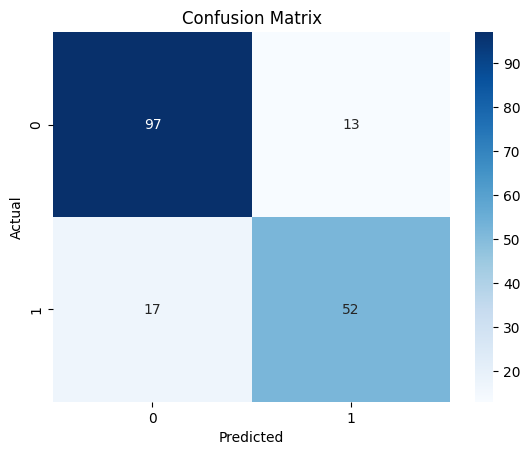

In [17]:
# 최고 성능 모델 상세 리포트

best_name = result_df.iloc[0]['Experiment']

print('Best Experiment:', best_name)

if best_name != 'Base':
    best_pred = predictions[best_name]

    print(
        classification_report(
            y_test,
            best_pred
        )
    )

    sns.heatmap(
        confusion_matrix(
            y_test,
            best_pred
        ),
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 추가 가산점 1: GridSearchCV 적용

In [18]:
grid_pipe = make_pipeline_config(
    impute_strategy='median',
    encoder='onehot',
    scaler='robust',
    feature_selection=True,
    model=RandomForestClassifier(
        random_state=RANDOM_STATE
    )
)

param_grid = {
    'feature_selection__k': [8, 10, 12],
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 5, None],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    grid_pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(
    'Best Params:',
    grid.best_params_
)

print(
    'Best CV F1:',
    grid.best_score_
)

grid_pred = grid.predict(X_test)

print(
    classification_report(
        y_test,
        grid_pred
    )
)

Best Params: {'feature_selection__k': 10, 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1: 0.7549707904416323
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       110
           1       0.69      0.70      0.69        69

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



## 추가 가산점 2: Feature Importance 시각화

,feature,importance
3,num__FarePerPerson,0.251569
1,num__Fare,0.224850
6,cat__Sex_male,0.134897
8,cat__Title_Mr,0.112323
5,cat__Sex_female,0.091527
0,num__Pclass,0.069320
4,num__HasCabin,0.050714
9,cat__Title_Mrs,0.022889
7,cat__Title_Miss,0.022670
2,num__IsAlone,0.019241


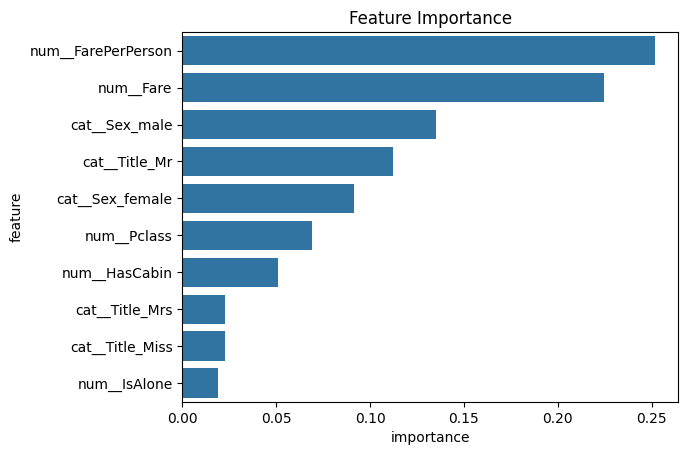

In [19]:
# GridSearchCV의 최적 RandomForest 모델 기준 중요도 시각화

best_estimator = grid.best_estimator_

rf_model = best_estimator.named_steps['model']

# SelectKBest 이후 feature name 추출
preprocess = best_estimator.named_steps['preprocess']

feature_names = preprocess.get_feature_names_out()

selector = best_estimator.named_steps['feature_selection']

selected_names = feature_names[
    selector.get_support()
]

importance_df = pd.DataFrame({
    'feature': selected_names,
    'importance': rf_model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

display(importance_df)

sns.barplot(
    data=importance_df,
    x='importance',
    y='feature'
)

plt.title('Feature Importance')
plt.show()

## GridSearchCV를 포함한 최종 성능 비교표 정리

In [20]:
grid_result_row = {
    'Experiment': 'GridSearchCV Best',
    'Accuracy': accuracy_score(y_test, grid_pred),
    'Precision': precision_score(y_test, grid_pred, zero_division=0),
    'Recall': recall_score(y_test, grid_pred, zero_division=0),
    'F1-score': f1_score(y_test, grid_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
}

final_result_df = pd.concat(
    [result_df, pd.DataFrame([grid_result_row])],
    ignore_index=True
).sort_values('F1-score', ascending=False).reset_index(drop=True)

display(final_result_df)

best_row = final_result_df.iloc[0]
print('최종 최고 성능 실험:', best_row['Experiment'])
print(f"최고 F1-score: {best_row['F1-score']:.4f}")

,Experiment,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Exp-1,0.832402,0.800000,0.753623,0.776119,0.875231
1,Exp-2,0.765363,0.701493,0.681159,0.691176,0.835310
2,GridSearchCV Best,0.759777,0.685714,0.695652,0.690647,0.820949
3,Exp-3,0.754190,0.676056,0.695652,0.685714,0.817918
4,Base,0.657343,0.581818,0.551724,0.566372,0.698377


최종 최고 성능 실험: Exp-1
최고 F1-score: 0.7761
